# Selection and read latency at a fixed row budget

Paper greedy and Saturation receive the same activation vector and requested row budget $R$. We compare the time needed to select and read rows, alongside the importance retained. Equal budgets can produce different masks and importance.

This projection-level experiment uses dense activation traces from 02 and a random weight-sized file. The [paper](https://arxiv.org/html/2511.18692v1) supplies the Paper selector and Appendix H tuning procedure; its main accuracy comparison is outside this experiment.

Fix 01's profile and 02's traces. Set `RUN_BENCHMARK = True` to tune and measure on the target SSD; `False` reads saved results. Rerun manually after changing inputs or settings. Run from this notebook's directory.

In [32]:
from pathlib import Path
from time import perf_counter_ns
from tempfile import TemporaryDirectory
import json, os, platform, subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from IPython.display import Markdown, display

PROFILE, TRACE = Path("../01/block_estimates.csv"), Path("../02/activation_traces.npz")
UPSTREAM = Path("../../../upstream/vlm-flash")
RESULTS, ENVIRONMENT = Path("measured_results.csv"), Path("measured_environment.json")
RUN_BENCHMARK = True
MAX_TRACES_PER_SHAPE = 32
FRACTIONS = np.arange(3, 11) / 10
WARMUP, REPEATS, THREADS = 3, 30, 6
PAPER, TILE = "Paper greedy (GPU sort)", "Saturation"

## Budget and retained importance

For a projection with $N$ rows, fraction $f$ gives $R=\max(1,\lfloor fN\rfloor)$. Archived importance is the mean absolute input activation, $v_i=\operatorname{mean}_{\rm batch,token}|x_i|$, normalized to mean one. A binary mask $M$ retains

$$q(M)=\frac{\sum_i v_iM_i}{\sum_i v_i},\qquad
\operatorname{fill}(M)=\frac{\sum_i M_i}{R}.$$

Paper may underfill; Saturation fills $R$. At $R=N$, both bypass selection. Zero-total importance leaves $q$ undefined. Up to `MAX_TRACES_PER_SHAPE` traces are sampled at evenly spaced archive positions within each shape.

In [33]:
if RUN_BENCHMARK:
    with np.load(TRACE, allow_pickle=False) as archive:
        manifest = json.loads(str(archive["manifest_json"].item()))
        traces = [{**t, "values": archive[t["array"]]} for t in manifest["traces"]]
    groups = [[t for t in traces if t["shape"] == shape] for shape in sorted({t["shape"] for t in traces})]
    traces = [g[i] for g in groups for i in np.linspace(0, len(g)-1,
              min(len(g), MAX_TRACES_PER_SHAPE or len(g)), dtype=int)]
    weight_bytes = {"float16": 2, "bfloat16": 2, "float32": 4}[manifest["model_dtype"]]
    curve = pd.read_csv(PROFILE).groupby("size_kib").latency_ms.median().sort_index()
    boundary, ceiling = float((curve / curve.index).idxmin()), float(curve.index.max())

## Cost and selection

The median profile defines $T(z)$ in milliseconds for $z$ KiB. Upstream interpolates between sizes, floors smaller reads at the minimum size, and extends the upper endpoint linearly. Mask cost sums $T$ over maximal selected runs; 02's fitted two-line model is unused.

Paper ranks windows by importance per cost and greedily accepts non-overlapping windows within $R$. Its ceiling is the largest profiled size. For $N\times d$ weights, a row occupies $w=d\,\text{bytes per weight}/1024$ KiB. Saturation uses

$$z_{\rm eff}\in\arg\min_z\frac{T(z)}z,\qquad B=\left\lceil\frac{z_{\rm eff}}w\right\rceil.$$

At offsets $0$ and $\lfloor B/2\rfloor$, Saturation takes the $\lfloor R/B\rfloor$ most important full tiles and the best disjoint interval of length $R\bmod B$. It keeps the mask with larger importance per modeled cost. If $R<B$, it takes the best length-$R$ interval.

Fresh runs require CUDA. Paper uses upstream's native selector with GPU sorting and CPU overlap checks; Saturation is compiled from `selectors.cpp`.

In [34]:
if RUN_BENCHMARK:
    import torch
    from torch.utils.cpp_extension import load
    os.environ.setdefault("MAX_JOBS", "1")
    torch.set_num_threads(1)
    sys.path[:0] = [str((UPSTREAM / p).resolve()) for p in ("scripts", "src")]
    import vlmflash
    from vlmflash._native import native
    from vlmflash.policy import _window_sweep
    from profile_flash import write_blob, exclusive
    assert Path(vlmflash.__file__).resolve().is_relative_to(UPSTREAM.resolve())
    reader = native()
    assert reader is not None and torch.cuda.is_available(), "Native reader and CUDA required."
    selectors = load("vlmflash_selection03", [str(Path("selectors.cpp").resolve())],
                     extra_cflags=["-O3", "-std=c++17"], verbose=False)
    table = vlmflash.LatencyTable(curve.to_dict())

## Window tuning

Upstream's Appendix H tuner uses random importance, sparsity 0.1, 30 repetitions, a 4–64 KiB grid in 4 KiB steps, and a 2 ms budget with a 20% margin. It chooses fine feasible windows, falling back to the fastest configuration if necessary. Tuning includes wrapper setup; its times differ in scope from the prepared calls below.

In [35]:
def tune_windows(work):
    profile_path, tuned_path = Path(work) / "profile.json", Path(work) / "tuned.json"
    profile_path.write_text(json.dumps(dict(format="vlmflash-latency-table-v1", table=curve.to_dict())))
    subprocess.run([sys.executable, str(UPSTREAM / "scripts/tune_chunk_params.py"),
        "--profile", str(profile_path), "--shapes", *sorted({t["shape"] for t in traces}),
        "--dtype-bytes", str(weight_bytes), "--impl", "native", "--output", str(tuned_path)],
        env={**os.environ, "OMP_NUM_THREADS": "1", "MKL_NUM_THREADS": "1"}, check=True)
    return json.loads(tuned_path.read_text())

## Preparing one trace

Both selectors share normalized importance and the cost lookup. Row width, candidate windows and cost tensors are prepared once per trace, outside timing. The returned functions take only the requested budget.

In [36]:
def prepare(trace):
    v = trace["values"].astype(np.float32)
    values = torch.from_numpy(v / v.mean() if v.any() else v)
    row_bytes = weight_bytes * trace["d"]
    w, tuned = row_bytes / 1024, tuning[trace["shape"]]["best"]
    B = int(np.ceil(boundary / w))
    costs = torch.tensor([0.] + [table.read_ms(w*r) for r in range(1, len(v)+1)], dtype=torch.float64)
    params = vlmflash.ChunkParams(start_kb=tuned["start_kb"], jump_cap_kb=tuned["jump_cap_kb"])
    windows, stride = _window_sweep(len(v), w, table, params)
    sizes = torch.tensor([r for r, _ in windows], dtype=torch.int64)
    delays = torch.tensor([t for _, t in windows], dtype=torch.float64)
    methods = {PAPER: lambda R: reader.select_chunks(values, R, sizes, delays, stride, True)[0],
               TILE: lambda R: selectors.tiles(values, R, costs, B)[0]}
    return values, row_bytes, B, costs, methods

Before timing, each mask is checked against its budget. Its selected intervals, importance, fill and modeled cost are recorded once and reused across repetitions.

In [37]:
def describe(mask, values, R, costs, method):
    selected, total = int(mask.sum()), float(values.double().sum())
    assert selected <= R if method == PAPER else selected == R
    spans = np.flatnonzero(np.diff(np.r_[False, mask.numpy().astype(bool), False])).reshape(-1, 2)
    return dict(R_selected=selected, fill_pct=100*selected/R,
        retained_pct=100*float(values[mask.bool()].double().sum())/total if total else np.nan,
        modeled_io_ms=float(costs[np.diff(spans).ravel()].sum()), runs=len(spans),
        intervals=json.dumps(spans.tolist()))

## Timing one selection and read

Let $t_0$ precede selection, $t_1$ follow it, and $t_2$ follow reader return:

$$t_{\rm selection}=t_1-t_0,\qquad t_{\rm wall}=t_2-t_0.$$

Native `io_ms` measures its read/thread interval; wall time also includes read preparation. Paper's GPU score transfers are included in selection. GPU weight transfer and model computation are excluded. Reads merge adjacent rows, use `THREADS` threads and split requests at 768 KiB. Validation follows the timed interval.

In [38]:
def timed_read(select, R, expected, blob, row_bytes):
    full = R == expected.numel()
    begin = perf_counter_ns()
    mask = expected if full else select(R)
    after_select = perf_counter_ns()
    raw, io_us, _, direct = reader.read_rows(blob, mask, row_bytes, "cpu", THREADS, 768*1024, True)
    end = perf_counter_ns()
    assert direct, "O_DIRECT unavailable; refusing page-cache timings."
    assert torch.equal(mask, expected) and raw.shape == (int(expected.sum()), row_bytes)
    return dict(selection_ms=(after_select-begin)/1e6, io_ms=io_us/1000, wall_ms=(end-begin)/1e6)

## Sweeping the budget

For each trace and fraction, run `WARMUP` rounds followed by `REPEATS` recorded rounds, with methods randomly interleaved. The all-rows case reuses a prepared dense mask. Each yielded record describes one measured repetition.

In [39]:
def measure_trace(trace, blob, rng):
    values, row_bytes, B, costs, methods = prepare(trace)
    N, dense = len(values), torch.ones(len(values), dtype=torch.uint8)
    for fraction in FRACTIONS:
        R, checked = max(1, int(round(float(fraction), 6)*N)), {}
        for name, select in methods.items():
            mask = dense if R == N else select(R)
            checked[name] = (mask.clone(), describe(mask, values, R, costs, name))
        for repeat in range(-WARMUP, REPEATS):
            for name in rng.permutation(list(methods)):
                mask, description = checked[name]
                timing = timed_read(methods[name], R, mask, blob, row_bytes)
                if repeat >= 0:
                    yield dict(trace_id=trace["trace_id"], shape=trace["shape"], fraction=float(fraction),
                        R_nominal=R, tile_rows=B, method=name, repeat=repeat, **timing, **description)

The run tunes windows, writes and fsyncs a random file on the target filesystem, then measures each trace. The CSV retains every repetition and selected interval.

In [40]:
if RUN_BENCHMARK:
    rng, records = np.random.default_rng(0), []
    with exclusive("03_paper_saturation"), TemporaryDirectory(dir=RESULTS.parent) as work:
        tuning = tune_windows(work)
        blob = str(Path(work) / "rows.dat")
        write_blob(blob, max(t["n"] * t["d"] * weight_bytes for t in traces))
        for index, trace in enumerate(traces, 1):
            records.extend(measure_trace(trace, blob, rng))
            if index % 16 == 0 or index == len(traces):
                print(f"{index}/{len(traces)} traces measured", flush=True)
    pd.DataFrame(records).to_csv(RESULTS, index=False)

4864x896: start=8KB jump=12KB overhead=1.58ms utility=3246.608 (245/256 configs under 2.0ms)
896x128: start=4KB jump=4KB overhead=0.167ms utility=21392.786 (256/256 configs under 2.0ms)
896x4864: start=4KB jump=4KB overhead=1.204ms utility=605.672 (36/36 configs under 2.0ms)
896x896: start=4KB jump=4KB overhead=1.177ms utility=3112.827 (256/256 configs under 2.0ms)
wrote /home/yabsed/Documents/fall26/work/graduate-paper/vlm-in-flash/conclusion/python/results/03/tmpeo_iaaih/tuned.json
creating 8 MB blob at /home/yabsed/Documents/fall26/work/graduate-paper/vlm-in-flash/conclusion/python/results/03/tmpeo_iaaih/rows.dat
16/128 traces measured
32/128 traces measured
48/128 traces measured
64/128 traces measured
80/128 traces measured
96/128 traces measured
112/128 traces measured
128/128 traces measured


## Measurement record

Save the device, tuning and acquisition settings alongside the CSV. These describe the measurement session used by the report.

In [41]:
if RUN_BENCHMARK:
    environment = dict(platform=platform.platform(), torch=torch.__version__, cuda_available=torch.cuda.is_available(),
        paper_sort_devices=["cuda"], paper_tuning=tuning,
        torch_threads=torch.get_num_threads(), reader_threads=THREADS, direct_io=True, destination="cpu",
        tile_boundary_kib=boundary, paper_ceiling_kib=ceiling, traces=len(traces),
        warmup=WARMUP, repeats=REPEATS, fractions=FRACTIONS.tolist(), max_read_kib=768,
        measurement="prepared CPU importance through selected bytes on CPU; no model compute",
        upstream_commit=subprocess.check_output(["git","-C",str(UPSTREAM),"rev-parse","HEAD"],text=True).strip(),
        mount=subprocess.check_output(["findmnt","-T",str(RESULTS.resolve()),"-n","-o","SOURCE,FSTYPE,TARGET"],text=True).strip())
    ENVIRONMENT.write_text(json.dumps(environment, indent=2))

The report reads saved measurements and their environment. Missing or empty data stops execution; input changes are managed manually.

In [42]:
frame = pd.read_csv(RESULTS)
assert not frame.empty, "Run the measurement before evaluating the report."
environment = json.loads(ENVIRONMENT.read_text())
display(pd.Series(environment)[["platform", "torch", "reader_threads", "warmup", "repeats", "traces",
                                "direct_io", "tile_boundary_kib", "paper_ceiling_kib", "mount"]])
if "paper_tuning" in environment:
    display(pd.DataFrame({shape: {**t["best"], "feasible": t["num_feasible"]}
                          for shape, t in environment["paper_tuning"].items()}).T)
else:
    display(Markdown("**Saved run:** window tuning was not recorded. The analysis below uses the "
                     "existing measurements; rerun to apply and record the upstream tuning protocol."))
frame = frame[frame.method.isin([PAPER, TILE])].copy()
assert set(frame.method) == {PAPER, TILE}, "Measure both selectors before comparing them."
assert np.isfinite(frame.io_ms).all() and (frame.io_ms > 0).all(), "I/O times must be positive."

platform             Linux-7.2.5-200.fc44.x86_64-x86_64-with-glibc2.43
torch                                                     2.11.0+cu130
reader_threads                                                       6
warmup                                                               3
repeats                                                             30
traces                                                             128
direct_io                                                         True
tile_boundary_kib                                                256.0
paper_ceiling_kib                                                768.0
mount                                /dev/nvme1n1p3[/home] btrfs /home
dtype: object

,start_kb,jump_cap_kb,overhead_ms,est_read_ms,utility,rows_selected,feasible
4864x896,8.0,12.0,1.580,1.353,3246.608,4376.0,245.0
896x128,4.0,4.0,0.167,0.037,21392.786,800.0,256.0
896x4864,4.0,4.0,1.204,1.359,605.672,807.0,36.0
896x896,4.0,4.0,1.177,0.262,3112.827,806.0,256.0


## Observed time and retained importance

Take repetition medians within each trace/method/budget case. Require both methods at every requested $R$. The table summarizes cases by shape and method, including the all-rows control. Undefined importance is omitted only from importance summaries.

In [43]:
values = ["selection_ms", "io_ms", "wall_ms", "retained_pct", "fill_pct"]
keys = ["shape", "trace_id", "fraction", "R_nominal"]
cases = frame.groupby(keys + ["method"])[values + ["R_selected"]].median().reset_index()
assert cases.groupby(keys).method.nunique().eq(2).all(), "Each budget needs both methods."
display(cases.groupby(["shape", "method"])[values].median().round(4))

selection_ms   io_ms  wall_ms  retained_pct  \
shape    method                                                                 
4864x896 Paper greedy (GPU sort)        1.7962  1.2311   2.9469       71.7672   
         Saturation                     0.0366  1.4211   1.4962       69.9443   
896x128  Paper greedy (GPU sort)        0.1052  0.1526   0.2797       68.5282   
         Saturation                     0.0053  0.1611   0.1857       66.9594   
896x4864 Paper greedy (GPU sort)        1.4624  1.2280   2.5942       70.0392   
         Saturation                     0.0189  1.4259   1.4853       68.7398   
896x896  Paper greedy (GPU sort)        1.0341  0.4060   1.4542       75.8773   
         Saturation                     0.0101  0.4559   0.4906       73.8598   

                                  fill_pct  
shape    method                             
4864x896 Paper greedy (GPU sort)   99.9629  
         Saturation               100.0000  
896x128  Paper greedy (GPU sort)   98.7898  
         Saturation               100.0000  
896x4864 Paper greedy (GPU sort)  100.0000  
         Saturation               100.0000  
896x896  Paper greedy (GPU sort)  100.0000  
         Saturation               100.0000

Each curve point takes medians across traces at one requested fraction, in increasing fraction order. For each shape, all three time plots share a zero-based range and ticks.

In [44]:
points = cases.groupby(["shape", "method", "fraction"])[values].median().reset_index()
metrics = (("io_ms", "I/O latency", "I/O time (ms)"),
           ("selection_ms", "Mask selection", "Selection time (ms)"),
           ("wall_ms", "Selection to read completion", "Elapsed time (ms)"))
limits = {shape: MaxNLocator(nbins=4).tick_values(0, group[[m[0] for m in metrics]].max().max()*1.05)
          for shape, group in points.groupby("shape")}

The three figures show read I/O, mask selection and the measured interval from selection start to CPU read completion. They display observed trade-offs; no equal-importance latency is inferred.

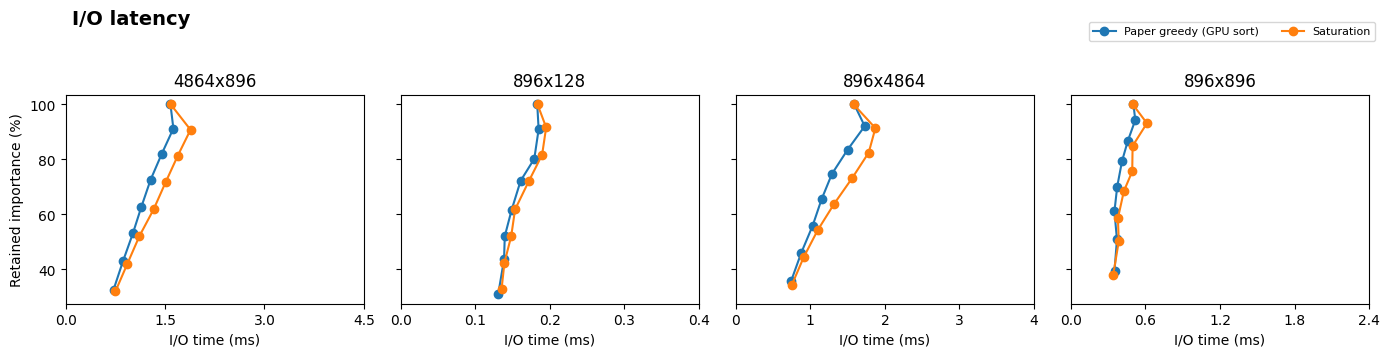

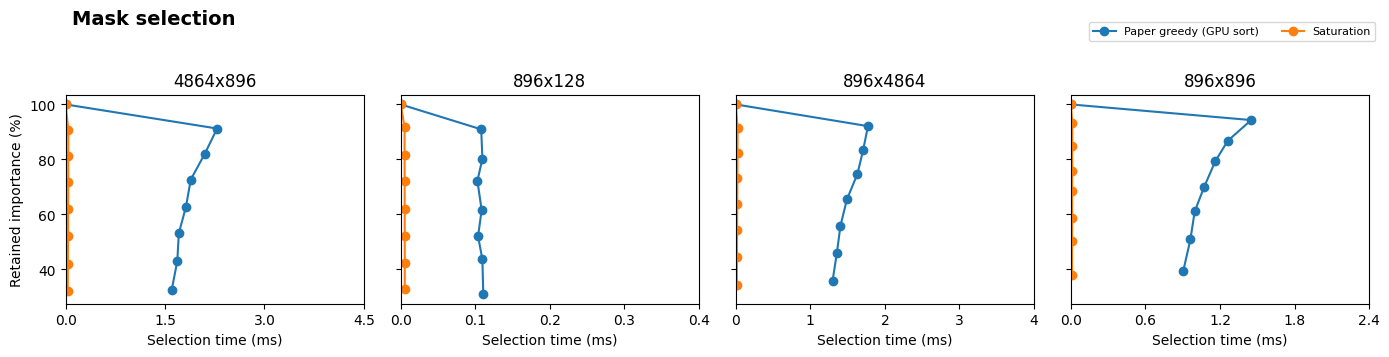

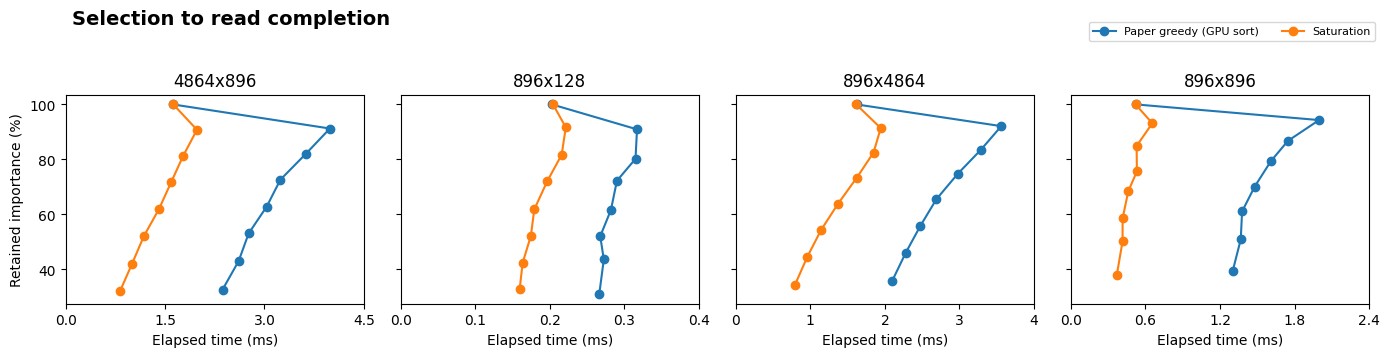

In [45]:
for metric, title, xlabel in metrics:
    fig, axes = plt.subplots(1, len(limits), figsize=(14, 3.6), squeeze=False, sharey=True)
    fig.suptitle(title, x=.055, ha="left", fontsize=14, fontweight="semibold")
    for column, (ax, (shape, group)) in enumerate(zip(axes.flat, points.groupby("shape"))):
        for name, data in group.groupby("method"):
            ax.plot(data[metric], data.retained_pct, "o-", label=name)
        ticks = limits[shape]
        ax.set(title=shape, xlabel=xlabel, xlim=(0, ticks[-1]), xticks=ticks,
               ylabel="Retained importance (%)" if column == 0 else "")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(.99, .96), ncol=2, fontsize=8)
    fig.tight_layout(rect=(0, 0, 1, .94))
    plt.show()

## Reading the comparison

Subtract Paper from Saturation within each trace and requested budget, then take medians by shape. Negative time differences favor Saturation; positive importance differences mean it retains more importance. Percentage differences are in percentage points. Component medians are not added.

These results describe the time–importance trade-off at the same requested budget, rather than equal accuracy or full-model inference speedup.

In [46]:
paper = cases[cases.method == PAPER]
filled = int(paper.R_selected.eq(paper.R_nominal).sum())
display(Markdown(f"Across **{len(paper):,}** paired trace/budget cases, Paper fills $R$ exactly in "
    f"**{filled:,}**; its median fill is **{paper.fill_pct.median():.2f}%**. "
    "The differences below use the same requested budgets, which may retain different importance."))
paired = cases.set_index(keys + ["method"])[values]
differences = paired.xs(TILE, level="method") - paired.xs(PAPER, level="method")
display(differences.groupby("shape").median().rename(columns={
    "selection_ms": "Δ selection (ms)", "io_ms": "Δ I/O (ms)", "wall_ms": "Δ wall (ms)",
    "retained_pct": "Δ importance (pp)", "fill_pct": "Δ fill (pp)"}).round(4))

Across **1,024** paired trace/budget cases, Paper fills $R$ exactly in **608**; its median fill is **100.00%**. The differences below use the same requested budgets, which may retain different importance.

,Δ selection (ms),Δ I/O (ms),Δ wall (ms),Δ importance (pp),Δ fill (pp)
shape,,,,,
4864x896,-1.7595,0.1233,-1.6172,-0.7254,0.0371
896x128,-0.0998,0.0064,-0.0955,0.1079,1.2102
896x4864,-1.4447,0.0943,-1.3355,-1.1530,0.0000
896x896,-1.0236,0.0217,-0.9977,-1.4988,0.0000
